# Correlations of insulation scores - Figure 1B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bioframe as bf
from scipy import stats
from pathlib import Path

In [2]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Load data for boundary strengths as dataframes

In [7]:
# Function to load bigwig data as dataframe
def bw_to_df(path, chroms):
    holder = list()
    for chrom in chroms:
        try:
            df = bf.read_bigwig(path, chrom)
            holder.append(df)
        except KeyError:
            pass
    return pd.concat(holder, ignore_index=True)

In [4]:
# Define path to boundary strength data (bigwig files)
repo = Path('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/boundary_strength/downsampled/')
strength_paths = {cond: str(repo / f"bs.{cond}.bw")
                  for cond in ('WT_G2', 'WT_G1', 'Prometa', 'dSororin_G2', 'WT_G2_BR1n2', 'WT_G2_BR3_ds_1n2')}

In [6]:
# Get chromosome sizes
hg19_chromsizes = bf.fetch_chromsizes('hg19')

In [8]:
# Load boundary strength data as dataframe
ins_tables = {cond: bw_to_df(path, hg19_chromsizes.index).assign(norm_value=lambda df: df['value'] - np.nanmedian(df['value']))
              for cond, path in strength_paths.items()}

## Set up pairs for comparison

In [9]:
comparison_pairs = [('WT_G2', cond)
                    for cond in ins_tables.keys()
                    if not cond.startswith('WT_G2')] \
                   + [('WT_G2_BR1n2', 'WT_G2_BR3_ds_1n2')]

In [10]:
for pair in comparison_pairs:
    print(pair[0], pair[1], sep='\t')

WT_G2	WT_G1
WT_G2	Prometa
WT_G2	dSororin_G2
WT_G2_BR1n2	WT_G2_BR3_ds_1n2


## Functions for the analysis

In [11]:
def make_label_replicate(cond1, cond2):
    if 'BR' in cond1:
        label = 'replicates'
        replicate = 'replicate'
    else:
        label = cond2
        replicate = 'condition'
    return label, replicate

In [12]:
def make_correlations_df(tables, comparison_pairs, view_df=None):
    holder = list()
    for cond1, cond2 in comparison_pairs:
        label, replicate = make_label_replicate(cond1, cond2)
        col = 'norm_value'
        df1 = tables[cond1][['chrom', 'start', 'end', col]]
        df2 = tables[cond2][['chrom', 'start', 'end', col]]
        df_comp = pd.merge(df1, df2, on=('chrom', 'start', 'end'), suffixes=('_1', '_2'))
        if view_df is not None:
            df_comp = bf.overlap(df_comp, view_df, how='inner')

        x = col + '_1'
        y = col + '_2'
        dummy = df_comp[['chrom', x, y]].dropna()
        for chrom, chrom_df in dummy.groupby('chrom', observed=True):
            if chrom == 'chrY':
                continue
            r = stats.pearsonr(chrom_df[x], chrom_df[y]).statistic
            rS = stats.spearmanr(chrom_df[x], chrom_df[y]).statistic
            
            record = {'chrom': chrom,
                      'cond1': cond1,
                      'cond2': cond2,
                      'pearson': r,
                      'spearman': rS,
                      'label': label,
                      'replicate': replicate}
            holder.append(record)
    correlations_df = pd.DataFrame.from_records(holder)
    return correlations_df

## Plot Correlation coefficients

In [14]:
corr_df = make_correlations_df(ins_tables, comparison_pairs)

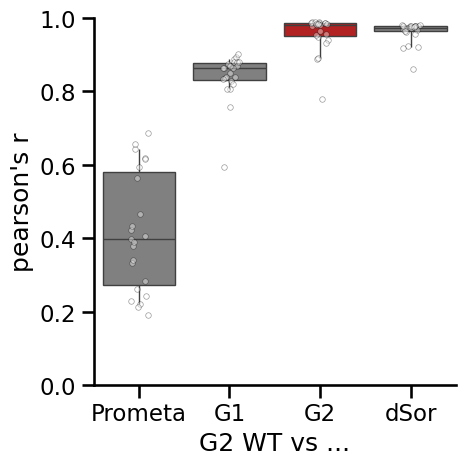

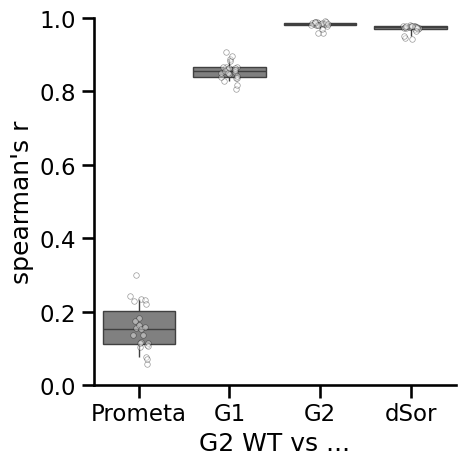

In [19]:
for metric in ('pearson', 'spearman'):
    with sns.plotting_context('talk'):
        plt.figure(figsize=(5, 5))
        sns.boxplot(data=corr_df,
                    y=metric,
                    x='label',
                    hue='replicate',
                    legend=False,
                    palette={'replicate': 'firebrick', 'condition': '.5'},
                    saturation=1,
                    order=['Prometa', 'WT_G1', 'replicates', 'dSororin_G2'],
                    fliersize=0,
                    whis=(5, 95),
                    showcaps=False)
        sns.stripplot(data=corr_df,
                      y=metric,
                      x='label',
                      alpha=.4,
                      legend=False,
                      color='w',
                      edgecolor='k',
                      linewidth=.5,
                      size=4)
        plt.xticks(ticks=range(4), labels=['Prometa', 'G1', 'G2', 'dSor'])
        plt.ylim(0, 1)
        plt.xlabel('G2 WT vs ...')
        plt.ylabel(f'{metric}\'s r')
        sns.despine()
        plt.tight_layout()